### 9 ions

/var/folders/s8/dpnknm2j0kj9ww1r_nvtxdrr0000gq/T/ipykernel_28061/3567156454.py:114: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


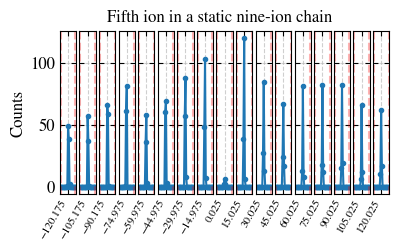

In [74]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import find_peaks

# -------------------------------------------------
# 0)  Global aesthetics   (unchanged)
# -------------------------------------------------
matplotlib.rcParams.update(
    {
        "font.family": "STIXGeneral",
        "xtick.labelsize": 12,
        "xtick.direction": "in",
        "xtick.major.pad": 3,
        "xtick.top": True,
        "ytick.labelsize": 12,
        "ytick.direction": "in",
        "ytick.right": True,
        "axes.labelsize": 12,
        "axes.labelpad": 3,
        "axes.grid": True,
    }
)
plt.rcParams.update({"font.size": 12})

# -------------------------------------------------
# 1)  Load your data
# -------------------------------------------------
final_result = np.load("final_result_static_9_ion_chain.npy")
index        = np.load("final_result_static_9_ion_chain_index.npy")

# --- Rebin to a 0.20 µs time bin ---
native_step = np.abs(index[1] - index[0])
target_step = 0.20
if not np.isclose(native_step, target_step):
    bin_factor = int(round(target_step / native_step))
    trimmed = (len(index) // bin_factor) * bin_factor
    if trimmed != len(index):
        index = index[:trimmed]
        final_result = final_result[:trimmed]
    index = index.reshape(-1, bin_factor).mean(axis=1)
    final_result = final_result.reshape(-1, bin_factor).sum(axis=1)

# Prevent negative counts from appearing in plots
final_result = np.clip(final_result, 0, None)


# -------------------------------------------------
# 2)  Detect peaks
# -------------------------------------------------
peak_threshold = 0.01 * np.max(final_result)
peaks, _       = find_peaks(final_result, height=peak_threshold)

# -------------------------------------------------
# 3)  Build windows around each peak
# -------------------------------------------------
window   = 10
segments = [(max(0, p - window), min(len(final_result), p + window + 1))
            for p in peaks]

# -------------------------------------------------
# 4)  Merge overlapping windows
# -------------------------------------------------
segments.sort()
merged_segments = []
for seg in segments:
    if not merged_segments:
        merged_segments.append(seg)
    else:
        last_seg = merged_segments[-1]
        if seg[0] <= last_seg[1]:                      # overlap → extend
            merged_segments[-1] = (last_seg[0], max(last_seg[1], seg[1]))
        else:
            merged_segments.append(seg)

# -------------------------------------------------
# 5)  Plot
# -------------------------------------------------
n_segments = len(merged_segments)
if n_segments == 0:
    print("No peaks found above threshold.")
else:
    fig, axs = plt.subplots(
        1, n_segments,
        figsize=(8.5/2, 4.25/2),    # unchanged
        sharey=True
    )
    if n_segments == 1:             # make iterable if only one subplot
        axs = [axs]

    for ax, (start, end) in zip(axs, merged_segments):
        seg_x = index[start:end]
        seg_y = final_result[start:end]

        ax.plot(seg_x, seg_y, marker='.', linestyle='-')
        ax.grid(True, which='both', linestyle='--', alpha=0.6)

        # window edge markers
        ax.axvline(seg_x[0],  color='r', linestyle='--', alpha=0.3)
        ax.axvline(seg_x[-1], color='r', linestyle='--', alpha=0.3)

        # ----------  X–axis formatting (ONE label per panel) ----------
        centre_tick = seg_x[len(seg_x) // 2]          # midpoint value
        ax.set_xticks([centre_tick])
        # If you prefer the first value instead, use: ax.set_xticks([seg_x[0]])
        ax.tick_params(axis='x', labelrotation=60, labelsize=8, pad=2)
        plt.setp(ax.get_xticklabels(), ha='right')
        # -------------------------------------------------------------

    axs[0].set_ylabel("Counts", fontsize=12)
    fig.suptitle("Fifth ion in a static nine-ion chain", fontsize=12)

    fig.tight_layout()
    plt.savefig('/Users/bingran_you/Documents/GitHub_MacBook/Multiplexing/outputs/g2/Fifth ion in a static nine-ion chain.pdf', format='pdf', bbox_inches='tight')
    plt.show()

/var/folders/s8/dpnknm2j0kj9ww1r_nvtxdrr0000gq/T/ipykernel_28061/1469799102.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


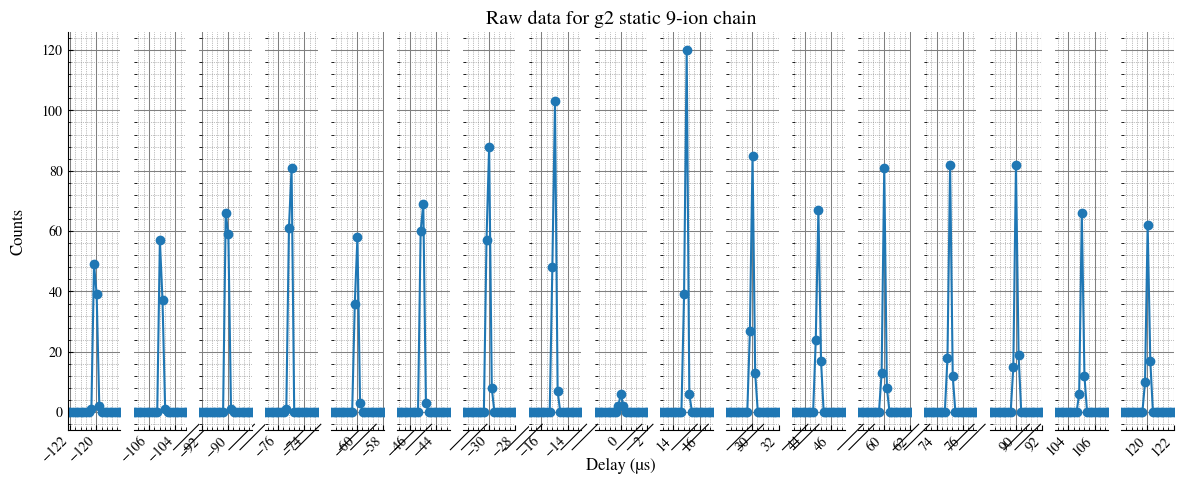

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from brokenaxes import brokenaxes
import matplotlib.ticker as ticker

final_result = np.load("final_result_static_9_ion_chain.npy")
index = np.load("final_result_static_9_ion_chain_index.npy")

# --- Rebin to a 0.20 µs time bin ---
native_step = np.abs(index[1] - index[0])
target_step = 0.20
if not np.isclose(native_step, target_step):
    bin_factor = int(round(target_step / native_step))
    trimmed = (len(index) // bin_factor) * bin_factor
    if trimmed != len(index):
        index = index[:trimmed]
        final_result = final_result[:trimmed]
    index = index.reshape(-1, bin_factor).mean(axis=1)
    final_result = final_result.reshape(-1, bin_factor).sum(axis=1)


# Suppose you already have:
# index         -> x-values
# final_result  -> y-values from your correlation measurement

# 1) Detect peaks
peak_threshold = 0.01 * np.max(final_result)
peaks, _ = find_peaks(final_result, height=peak_threshold)

# 2) Define a window around each peak
window = 10
segments = []
for p in peaks:
    start = max(0, p - window)
    end   = min(len(final_result), p + window + 1)
    segments.append((start, end))

# 3) Merge overlapping segments
segments.sort()
merged_segments = []
for seg in segments:
    if not merged_segments:
        merged_segments.append(seg)
    else:
        last_seg = merged_segments[-1]
        if seg[0] <= last_seg[1]:
            merged_segments[-1] = (last_seg[0], max(last_seg[1], seg[1]))
        else:
            merged_segments.append(seg)

# 4) Convert merged segments into x‐range tuples
x_breaks = []
for (s, e) in merged_segments:
    # Map indices to actual x-values (e-1 because slicing is exclusive at the end)
    x_breaks.append((index[s], index[e-1]))

# x_breaks = [(index[s], index[e-1]) for (s, e) in merged_segments]

# 5) Create a figure with a "broken" x-axis for each segment
fig = plt.figure(figsize=(12, 5))
# bax = brokenaxes(xlims=x_breaks, hspace=.05)
bax = brokenaxes(xlims=x_breaks, d=0.015, hspace=.05, wspace=0.25)


# 6) Plot all data (brokenaxes splits the x‐axis automatically)
bax.plot(index, final_result, marker='o', linestyle='-')

# 7) Enhance grid density: add minor ticks and grid lines to each sub-axis
for ax in bax.axs:
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.grid(which='major', linestyle='-', linewidth=0.75, color='gray')
    ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
    plt.setp(ax.get_yticklabels(), fontsize=10)

# 8) Labeling with adjusted labelpad for the x-axis
bax.set_xlabel("Delay (µs)", labelpad=20)
bax.set_ylabel("Counts")
bax.set_title("Raw data for g2 static 9-ion chain")

plt.tight_layout()
plt.show()

### Single ion

/var/folders/s8/dpnknm2j0kj9ww1r_nvtxdrr0000gq/T/ipykernel_28061/2348684026.py:179: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


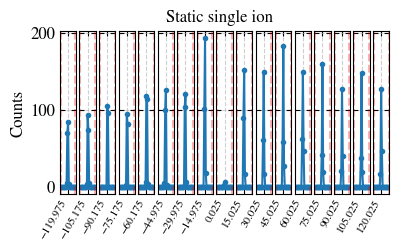

In [76]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import find_peaks

# final_result = np.load("final_result_static_single_ion.npy")
# index = np.load("final_result_static_single_ion_index.npy")

# # Suppose you already have: index (x-values) and final_result (y-values)
# # 1) Detect peaks
# peak_threshold = 0.01 * np.max(final_result)
# peaks, _ = find_peaks(final_result, height=peak_threshold)

# # 2) Define a window around each peak
# window = 10
# segments = []
# for p in peaks:
#     start = max(0, p - window)
#     end   = min(len(final_result), p + window + 1)
#     segments.append((start, end))

# # 3) Merge overlapping segments
# segments.sort()
# merged_segments = []
# for seg in segments:
#     if not merged_segments:
#         merged_segments.append(seg)
#     else:
#         last_seg = merged_segments[-1]
#         if seg[0] <= last_seg[1]:
#             merged_segments[-1] = (last_seg[0], max(last_seg[1], seg[1]))
#         else:
#             merged_segments.append(seg)

# # 4) Plot each merged segment in its own subplot
# n_segments = len(merged_segments)
# if n_segments == 0:
#     print("No peaks found above threshold.")
# else:
#     fig, axs = plt.subplots(
#         1, n_segments,  # one row, n_segments columns
#         figsize=(max(4.25, 2*n_segments), 4.25),
#         sharey=True      # share y-axis so all subplots have same scale
#     )
#     # If there is only one segment, axs is not a list; make it a list
#     if n_segments == 1:
#         axs = [axs]

#     for i, (start, end) in enumerate(merged_segments):
#         seg_x = index[start:end]
#         seg_y = final_result[start:end]

#         # Plot the segment
#         axs[i].plot(seg_x, seg_y, marker='o', linestyle='-')
#         # axs[i].set_title(f"Segment {i+1}\n[{seg_x[0]:.2f}, {seg_x[-1]:.2f}] µs")
#         axs[i].grid(True)

#         # # (Optional) Add vertical lines at the boundaries
#         # axs[i].axvline(seg_x[0], color='r', linestyle='--', alpha=0.3)
#         # axs[i].axvline(seg_x[-1], color='r', linestyle='--', alpha=0.3)

#     axs[0].set_ylabel("Counts")
#     fig.suptitle("Peak Regions in Separate Subplots (Zoomed)", fontsize=12)
#     plt.tight_layout()
#     plt.show()

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import find_peaks

# -------------------------------------------------
# 0)  Global aesthetics   (unchanged)
# -------------------------------------------------
matplotlib.rcParams.update(
    {
        "font.family": "STIXGeneral",
        "xtick.labelsize": 12,
        "xtick.direction": "in",
        "xtick.major.pad": 3,
        "xtick.top": True,
        "ytick.labelsize": 12,
        "ytick.direction": "in",
        "ytick.right": True,
        "axes.labelsize": 12,
        "axes.labelpad": 3,
        "axes.grid": True,
    }
)
plt.rcParams.update({"font.size": 12})

# -------------------------------------------------
# 1)  Load your data
# -------------------------------------------------
final_result = np.load("final_result_static_single_ion.npy")
index        = np.load("final_result_static_single_ion_index.npy")

# --- Rebin to a 0.20 µs time bin ---
native_step = np.abs(index[1] - index[0])
target_step = 0.20
if not np.isclose(native_step, target_step):
    bin_factor = int(round(target_step / native_step))
    trimmed = (len(index) // bin_factor) * bin_factor
    if trimmed != len(index):
        index = index[:trimmed]
        final_result = final_result[:trimmed]
    index = index.reshape(-1, bin_factor).mean(axis=1)
    final_result = final_result.reshape(-1, bin_factor).sum(axis=1)

# Prevent negative counts from appearing in plots
final_result = np.clip(final_result, 0, None)


# -------------------------------------------------
# 2)  Detect peaks
# -------------------------------------------------
peak_threshold = 0.01 * np.max(final_result)
peaks, _       = find_peaks(final_result, height=peak_threshold)

# -------------------------------------------------
# 3)  Build windows around each peak
# -------------------------------------------------
window   = 10
segments = [(max(0, p - window), min(len(final_result), p + window + 1))
            for p in peaks]

# -------------------------------------------------
# 4)  Merge overlapping windows
# -------------------------------------------------
segments.sort()
merged_segments = []
for seg in segments:
    if not merged_segments:
        merged_segments.append(seg)
    else:
        last_seg = merged_segments[-1]
        if seg[0] <= last_seg[1]:                      # overlap → extend
            merged_segments[-1] = (last_seg[0], max(last_seg[1], seg[1]))
        else:
            merged_segments.append(seg)

# -------------------------------------------------
# 5)  Plot
# -------------------------------------------------
n_segments = len(merged_segments)
if n_segments == 0:
    print("No peaks found above threshold.")
else:
    fig, axs = plt.subplots(
        1, n_segments,
        figsize=(8.5/2, 4.25/2),    # unchanged
        sharey=True
    )
    if n_segments == 1:             # make iterable if only one subplot
        axs = [axs]

    for ax, (start, end) in zip(axs, merged_segments):
        seg_x = index[start:end]
        seg_y = final_result[start:end]

        ax.plot(seg_x, seg_y, marker='.', linestyle='-')
        ax.grid(True, which='both', linestyle='--', alpha=0.6)

        # window edge markers
        ax.axvline(seg_x[0],  color='r', linestyle='--', alpha=0.3)
        ax.axvline(seg_x[-1], color='r', linestyle='--', alpha=0.3)

        # ----------  X–axis formatting (ONE label per panel) ----------
        centre_tick = seg_x[len(seg_x) // 2]          # midpoint value
        ax.set_xticks([centre_tick])
        # If you prefer the first value instead, use: ax.set_xticks([seg_x[0]])
        ax.tick_params(axis='x', labelrotation=60, labelsize=8, pad=2)
        plt.setp(ax.get_xticklabels(), ha='right')
        # -------------------------------------------------------------

    axs[0].set_ylabel("Counts", fontsize=12)
    fig.suptitle("Static single ion", fontsize=12)

    fig.tight_layout()
    plt.savefig('/Users/bingran_you/Documents/GitHub_MacBook/Multiplexing/outputs/g2/Static single ion.pdf', format='pdf', bbox_inches='tight')
    plt.show()

/var/folders/s8/dpnknm2j0kj9ww1r_nvtxdrr0000gq/T/ipykernel_28061/1711696277.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


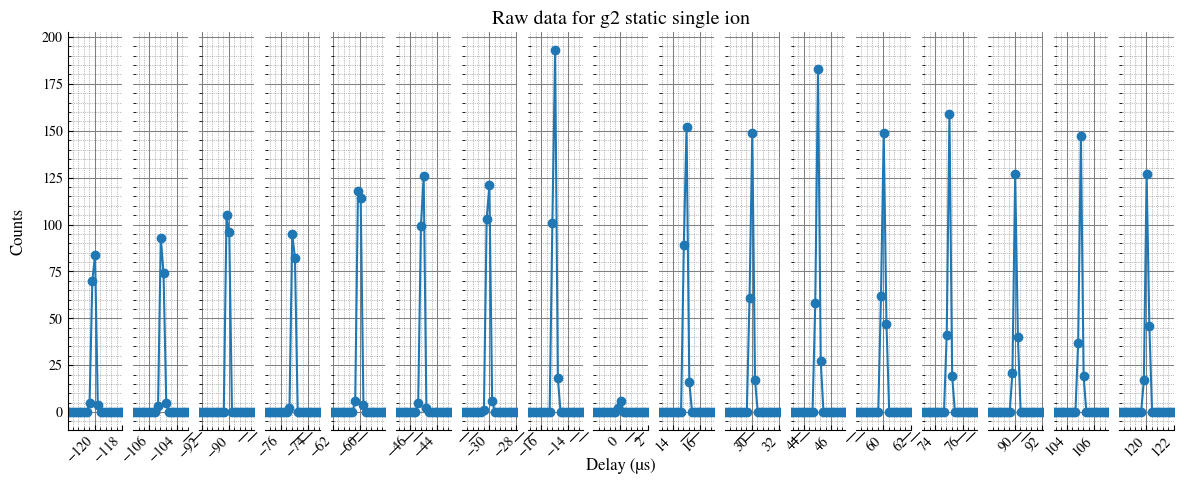

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from brokenaxes import brokenaxes
import matplotlib.ticker as ticker

final_result = np.load("final_result_static_single_ion.npy")
index = np.load("final_result_static_single_ion_index.npy")

# --- Rebin to a 0.20 µs time bin ---
native_step = np.abs(index[1] - index[0])
target_step = 0.20
if not np.isclose(native_step, target_step):
    bin_factor = int(round(target_step / native_step))
    trimmed = (len(index) // bin_factor) * bin_factor
    if trimmed != len(index):
        index = index[:trimmed]
        final_result = final_result[:trimmed]
    index = index.reshape(-1, bin_factor).mean(axis=1)
    final_result = final_result.reshape(-1, bin_factor).sum(axis=1)


# Suppose you already have:
# index         -> x-values
# final_result  -> y-values from your correlation measurement

# 1) Detect peaks
peak_threshold = 0.01 * np.max(final_result)
peaks, _ = find_peaks(final_result, height=peak_threshold)

# 2) Define a window around each peak
window = 10
segments = []
for p in peaks:
    start = max(0, p - window)
    end   = min(len(final_result), p + window + 1)
    segments.append((start, end))

# 3) Merge overlapping segments
segments.sort()
merged_segments = []
for seg in segments:
    if not merged_segments:
        merged_segments.append(seg)
    else:
        last_seg = merged_segments[-1]
        if seg[0] <= last_seg[1]:
            merged_segments[-1] = (last_seg[0], max(last_seg[1], seg[1]))
        else:
            merged_segments.append(seg)

# 4) Convert merged segments into x‐range tuples
x_breaks = []
for (s, e) in merged_segments:
    # Map indices to actual x-values (e-1 because slicing is exclusive at the end)
    x_breaks.append((index[s], index[e-1]))

# x_breaks = [(index[s], index[e-1]) for (s, e) in merged_segments]

# 5) Create a figure with a "broken" x-axis for each segment
fig = plt.figure(figsize=(12, 5))
# bax = brokenaxes(xlims=x_breaks, hspace=.05)
bax = brokenaxes(xlims=x_breaks, d=0.005, hspace=.05)


# 6) Plot all data (brokenaxes splits the x‐axis automatically)
bax.plot(index, final_result, marker='o', linestyle='-')

# 7) Enhance grid density: add minor ticks and grid lines to each sub-axis
for ax in bax.axs:
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.grid(which='major', linestyle='-', linewidth=0.75, color='gray')
    ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
    plt.setp(ax.get_yticklabels(), fontsize=10)

# 8) Labeling with adjusted labelpad for the x-axis
bax.set_xlabel("Delay (µs)", labelpad=20)
bax.set_ylabel("Counts")
bax.set_title("Raw data for g2 static single ion")

plt.tight_layout()
plt.show()

### Shuttling 9 ions

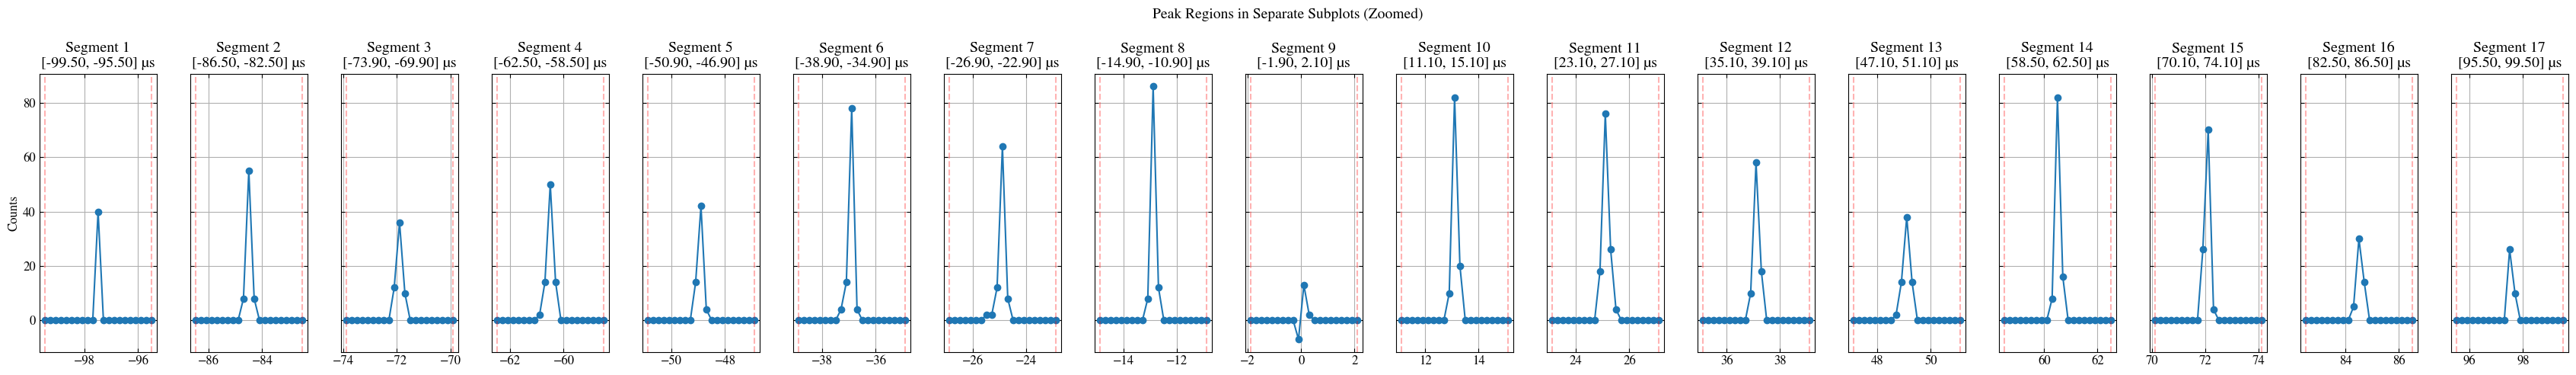

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

final_result = np.load("summed_caled_data.npy")
index = np.load("summed_caled_data_index.npy")

# Suppose you already have: index (x-values) and final_result (y-values)
# 1) Detect peaks
peak_threshold = 0.01 * np.max(final_result)
peaks, _ = find_peaks(final_result, height=peak_threshold)

# 2) Define a window around each peak
window = 10
segments = []
for p in peaks:
    start = max(0, p - window)
    end   = min(len(final_result), p + window + 1)
    segments.append((start, end))

# 3) Merge overlapping segments
segments.sort()
merged_segments = []
for seg in segments:
    if not merged_segments:
        merged_segments.append(seg)
    else:
        last_seg = merged_segments[-1]
        if seg[0] <= last_seg[1]:
            merged_segments[-1] = (last_seg[0], max(last_seg[1], seg[1]))
        else:
            merged_segments.append(seg)

# 4) Plot each merged segment in its own subplot
n_segments = len(merged_segments)
if n_segments == 0:
    print("No peaks found above threshold.")
else:
    fig, axs = plt.subplots(
        1, n_segments,  # one row, n_segments columns
        figsize=(max(10, 2*n_segments), 5),
        sharey=True      # share y-axis so all subplots have same scale
    )
    # If there is only one segment, axs is not a list; make it a list
    if n_segments == 1:
        axs = [axs]

    for i, (start, end) in enumerate(merged_segments):
        seg_x = index[start:end]
        seg_y = final_result[start:end]

        # Plot the segment
        axs[i].plot(seg_x, seg_y, marker='o', linestyle='-')
        axs[i].set_title(f"Segment {i+1}\n[{seg_x[0]:.2f}, {seg_x[-1]:.2f}] µs")
        axs[i].grid(True)

        # (Optional) Add vertical lines at the boundaries
        axs[i].axvline(seg_x[0], color='r', linestyle='--', alpha=0.3)
        axs[i].axvline(seg_x[-1], color='r', linestyle='--', alpha=0.3)

    axs[0].set_ylabel("Counts")
    fig.suptitle("Peak Regions in Separate Subplots (Zoomed)", fontsize=14)
    plt.tight_layout()
    plt.show()

/var/folders/s8/dpnknm2j0kj9ww1r_nvtxdrr0000gq/T/ipykernel_28061/152737133.py:173: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


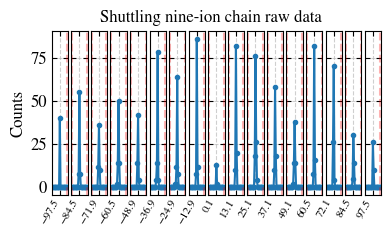

In [79]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import find_peaks
# from brokenaxes import brokenaxes
# import matplotlib.ticker as ticker

# final_result = np.load("summed_caled_data.npy")
# index = np.load("summed_caled_data_index.npy")

# # Suppose you already have:
# # index         -> x-values
# # final_result  -> y-values from your correlation measurement

# # 1) Detect peaks
# peak_threshold = 0.01 * np.max(final_result)
# peaks, _ = find_peaks(final_result, height=peak_threshold)

# # 2) Define a window around each peak
# window = 10
# segments = []
# for p in peaks:
#     start = max(0, p - window)
#     end   = min(len(final_result), p + window + 1)
#     segments.append((start, end))

# # 3) Merge overlapping segments
# segments.sort()
# merged_segments = []
# for seg in segments:
#     if not merged_segments:
#         merged_segments.append(seg)
#     else:
#         last_seg = merged_segments[-1]
#         if seg[0] <= last_seg[1]:
#             merged_segments[-1] = (last_seg[0], max(last_seg[1], seg[1]))
#         else:
#             merged_segments.append(seg)

# # 4) Convert merged segments into x‐range tuples
# x_breaks = []
# for (s, e) in merged_segments:
#     # Map indices to actual x-values (e-1 because slicing is exclusive at the end)
#     x_breaks.append((index[s], index[e-1]))

# # x_breaks = [(index[s], index[e-1]) for (s, e) in merged_segments]

# # 5) Create a figure with a "broken" x-axis for each segment
# fig = plt.figure(figsize=(12, 5))
# # bax = brokenaxes(xlims=x_breaks, hspace=.05)
# bax = brokenaxes(xlims=x_breaks, d=0.005, hspace=.05)


# # 6) Plot all data (brokenaxes splits the x‐axis automatically)
# bax.plot(index, final_result, marker='o', linestyle='-')

# # 7) Enhance grid density: add minor ticks and grid lines to each sub-axis
# for ax in bax.axs:
#     ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
#     ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
#     ax.grid(which='major', linestyle='-', linewidth=0.75, color='gray')
#     ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray')
#     plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
#     plt.setp(ax.get_yticklabels(), fontsize=10)

# # 8) Labeling with adjusted labelpad for the x-axis
# bax.set_xlabel("Delay (µs)", labelpad=20)
# bax.set_ylabel("Counts")
# bax.set_title("Raw data for g2 shuttling 9-ion")

# plt.tight_layout()
# plt.show()

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import find_peaks

# -------------------------------------------------
# 0)  Global aesthetics   (unchanged)
# -------------------------------------------------
matplotlib.rcParams.update(
    {
        "font.family": "STIXGeneral",
        "xtick.labelsize": 12,
        "xtick.direction": "in",
        "xtick.major.pad": 3,
        "xtick.top": True,
        "ytick.labelsize": 12,
        "ytick.direction": "in",
        "ytick.right": True,
        "axes.labelsize": 12,
        "axes.labelpad": 3,
        "axes.grid": True,
    }
)
plt.rcParams.update({"font.size": 12})

# -------------------------------------------------
# 1)  Load your data
# -------------------------------------------------
final_result = np.load("summed_caled_data.npy")
index        = np.load("summed_caled_data_index.npy")
# Prevent negative counts from appearing in plots
final_result = np.clip(final_result, 0, None)


# -------------------------------------------------
# 2)  Detect peaks
# -------------------------------------------------
peak_threshold = 0.01 * np.max(final_result)
peaks, _       = find_peaks(final_result, height=peak_threshold)

# -------------------------------------------------
# 3)  Build windows around each peak
# -------------------------------------------------
window   = 10
segments = [(max(0, p - window), min(len(final_result), p + window + 1))
            for p in peaks]

# -------------------------------------------------
# 4)  Merge overlapping windows
# -------------------------------------------------
segments.sort()
merged_segments = []
for seg in segments:
    if not merged_segments:
        merged_segments.append(seg)
    else:
        last_seg = merged_segments[-1]
        if seg[0] <= last_seg[1]:                      # overlap → extend
            merged_segments[-1] = (last_seg[0], max(last_seg[1], seg[1]))
        else:
            merged_segments.append(seg)

# -------------------------------------------------
# 5)  Plot
# -------------------------------------------------
n_segments = len(merged_segments)
if n_segments == 0:
    print("No peaks found above threshold.")
else:
    fig, axs = plt.subplots(
        1, n_segments,
        figsize=(8.5/2, 4.25/2),    # unchanged
        sharey=True
    )
    if n_segments == 1:             # make iterable if only one subplot
        axs = [axs]

    for ax, (start, end) in zip(axs, merged_segments):
        seg_x = index[start:end]
        seg_y = final_result[start:end]

        ax.plot(seg_x, seg_y, marker='.', linestyle='-')
        ax.grid(True, which='both', linestyle='--', alpha=0.6)

        # window edge markers
        ax.axvline(seg_x[0],  color='r', linestyle='--', alpha=0.3)
        ax.axvline(seg_x[-1], color='r', linestyle='--', alpha=0.3)

        # ----------  X–axis formatting (ONE label per panel) ----------
        centre_tick = seg_x[len(seg_x) // 2]          # midpoint value
        ax.set_xticks([centre_tick])
        # If you prefer the first value instead, use: ax.set_xticks([seg_x[0]])
        ax.tick_params(axis='x', labelrotation=60, labelsize=8, pad=2)
        plt.setp(ax.get_xticklabels(), ha='right')
        # -------------------------------------------------------------

    axs[0].set_ylabel("Counts", fontsize=12)
    fig.suptitle("Shuttling nine-ion chain raw data", fontsize=12)

    fig.tight_layout()
    plt.savefig('/Users/bingran_you/Documents/GitHub_MacBook/Multiplexing/outputs/g2/Shuttling nine-ion chain.pdf', format='pdf', bbox_inches='tight')
    plt.show()

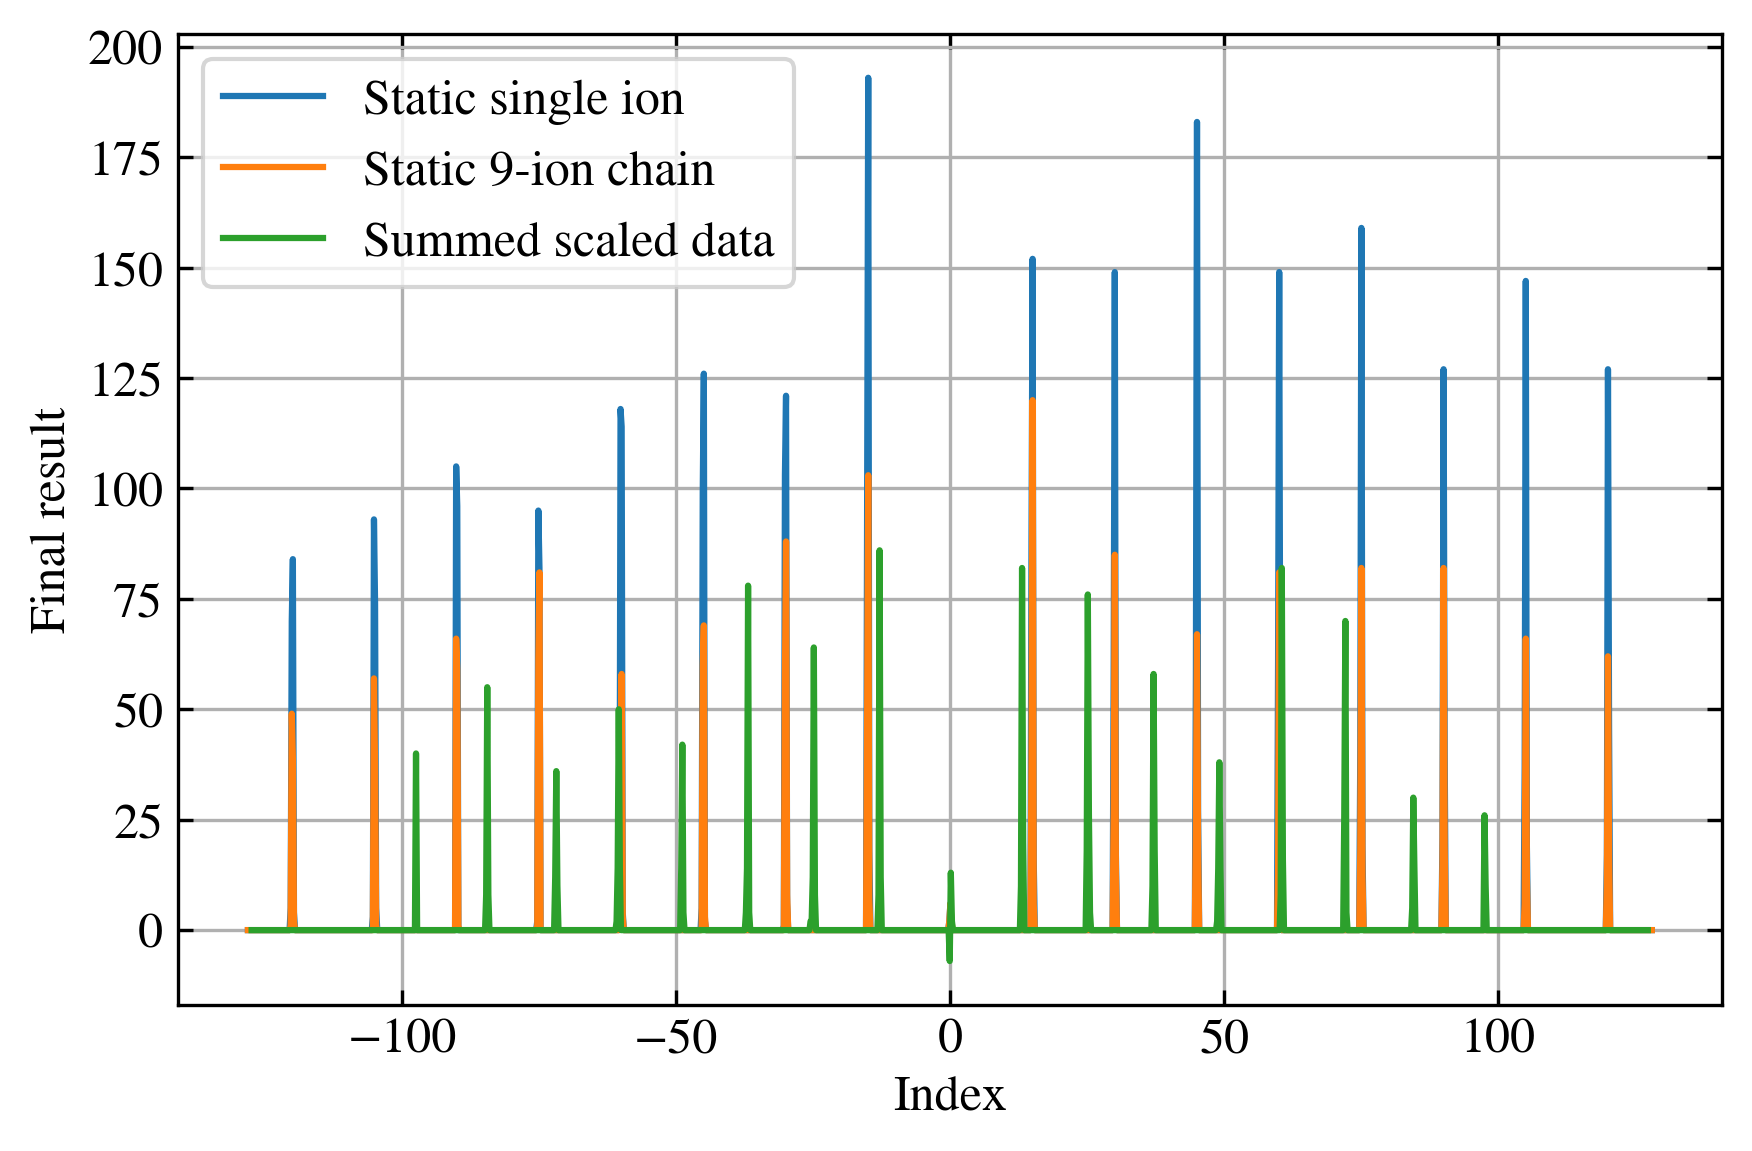

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

def rebin_to_target(index_array, counts_array, target_step=0.20):
    native_step = np.abs(index_array[1] - index_array[0]) if len(index_array) > 1 else target_step
    if np.isclose(native_step, target_step):
        return index_array, counts_array
    bin_factor = int(round(target_step / native_step))
    trimmed = (len(index_array) // bin_factor) * bin_factor
    if trimmed != len(index_array):
        index_array = index_array[:trimmed]
        counts_array = counts_array[:trimmed]
    index_array = index_array.reshape(-1, bin_factor).mean(axis=1)
    counts_array = counts_array.reshape(-1, bin_factor).sum(axis=1)
    return index_array, counts_array


# --- your global style settings ---
matplotlib.rcParams.update({
    "font.family": "STIXGeneral",
    "xtick.labelsize": 12,
    "xtick.direction": "in",
    "xtick.major.pad": 3,
    "xtick.top": True,
    "ytick.labelsize": 12,
    "ytick.direction": "in",
    "ytick.right": True,
    "axes.labelsize": 12,
    "axes.labelpad": 3,
    "axes.grid": True
})

# --- load each dataset ---
idx1 = np.load("final_result_static_single_ion_index.npy")

res1 = np.load("final_result_static_single_ion.npy")
idx1, res1 = rebin_to_target(idx1, res1, 0.20)


idx2 = np.load("final_result_static_9_ion_chain_index.npy")
res2 = np.load("final_result_static_9_ion_chain.npy")
idx2, res2 = rebin_to_target(idx2, res2, 0.20)


idx3 = np.load("summed_caled_data_index.npy")
res3 = np.load("summed_caled_data.npy")
idx3, res3 = rebin_to_target(idx3, res3, 0.20)


# --- make the plot ---
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

ax.plot(idx1, res1,    label="Static single ion")     # C0
ax.plot(idx2, res2,    label="Static 9-ion chain")    # C1
ax.plot(idx3, res3,    label="Summed scaled data")    # C2

ax.set_xlabel("Index")
ax.set_ylabel("Final result")
ax.legend(loc="best")
plt.tight_layout()
plt.show()
